In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
def load_doc(doc_path: str):
    loader = PyPDFLoader(doc_path)
    return loader 

def splitter(doc):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1200,
        chunk_overlap=300,
        separators=["\n\n", "\n", ". ", " ", ""],
        length_function=len,
    )
    return splitter.split_documents(doc)

def embed_retrieve(doc):
    embedding = OpenAIEmbeddings(model="text-embedding-3-large")
    vector_store = FAISS.from_documents(doc, embedding)
    retriever = vector_store.as_retriever(search_kwargs={"k": 2})
    return retriever
    


In [4]:
class GraphState(TypedDict):
    retriever_needed: bool = Field(..., description="Boolean indicating whether retrieval of documents is needed or not for a given user question")
    question: str = Field(..., description="User query")
    retrieved_documents: List[Document] = Field(description="List of retrieved documents")
    relevent_documents: List[Document] = Field(description="List of relevant documents")
    answer: str = Field(..., description="Answer to the user query")
    context: str = Field(..., description="Context of the relevent dcumnets")
    is_sup: Literal["Fully", "Partially", "No"] = Field(..., description="Whether the answer is fully relevent, partially relevent or not relevent")


In [5]:
decision_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful organisational assistant answering questions about HR policies and company documents."),
    ("human", "{question}")
])

In [6]:
class DecisionOutput(BaseModel):
    retriever_decision: bool = Field(..., description="Boolean indicating whether retrieval of documents is needed or not for a given user question")

In [7]:
class ReleventDocs(BaseModel):
    relevent: bool = Field(..., description="Boolean indicating whether retrieved docuemnts are relevent or not for a given user question")

In [8]:
llm = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0   
)

In [9]:
llm_structured_op = llm.with_structured_output(DecisionOutput)

/Users/siddhant/Desktop/projects/chatbot/myvenv/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1857: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [10]:
llm_structured_relevent = llm.with_structured_output(ReleventDocs)

In [11]:
def decision(state: GraphState):
    output = llm_structured_op.invoke(decision_prompt.format_messages(question=state["question"]))
    return {"retriever_needed": output.retriever_decision}

In [12]:


def retrieve(state: GraphState, embed_retriever):
    retriever = embed_retriever()
    return {"retrieved_documents": retriever.invoke(state["question"])}


In [13]:
def generate(state: GraphState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "xyz"),
        ("human", "{question}")
    ])

    output = llm.invoke(prompt.format_messages(question=state["question"]))
    return {"answer": output.content}
   

In [14]:
relevence_prompt = ChatPromptTemplate.from_messages([
    ("system", "xcc"),
    ("human", "{question}, {documents}")
])


def is_relevent(state: GraphState):
    relevent_docs: List[Document] = []
    for docs in state["retrieved_documents"]:
        output = llm_structured_relevent.invoke(relevence_prompt.format_messages(question=state["question"], documents=docs.page_content))
        if output.relevent:
            relevent_docs.append(docs)
    return {"relevent_documents": relevent_docs}

In [15]:
def generate_from_context(state: GraphState):
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevent_documents", [])]
    )

    context_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "xyz"),
            ("human", "{question}, {context}")
        ]
    )

    output = llm.invoke(context_prompt.format_messages(question=state["question"], context=context))
    return {"answer": output.content, "context": context}

In [16]:
class support(BaseModel):
    is_sup: Literal["Fully", "Partially", "No"] = Field(..., description="Whether the answer is fully relevent, partially relevent or not relevent")
    evidence: List[Document] = Field(default_factory=list)

llm_support = llm.with_structured_output(support)


def is_sup(state: GraphState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "xyz"),
        ("human", "{question}, {context}, {answer}")
    ])

    output = llm_support.invoke(prompt.format_messages(question=state["question"], context=state["context"], answer=state["answer"]))

    return {"is_sup": output.is_sup, "evidence": output.evidence}

In [17]:
def answer_not_found(state: GraphState):
    return {"answer": "No relevant information found"}

In [18]:
def route_after_decision(state: GraphState):
    if state["retriever_needed"]:
        return "retrieve"
    return "generate"

In [19]:
def route_after_is_relevent(state: GraphState):
    if state.get("relevent_documents") and len(state["relevent_documents"])>0:
        return "generate_from_context"
    return "answer_not_found"

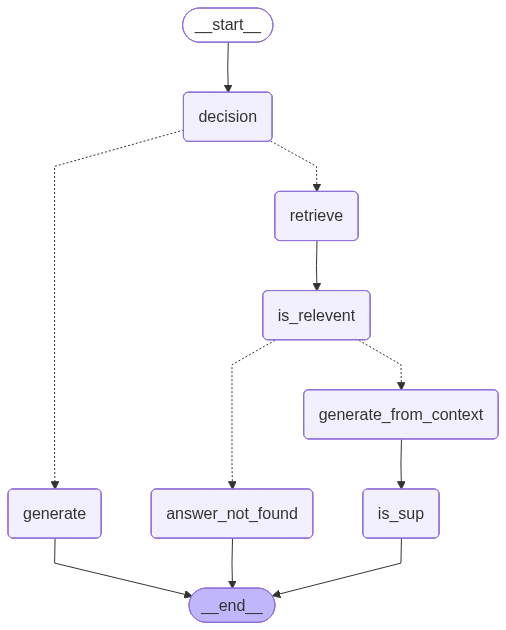

In [20]:
graph = StateGraph(GraphState)

graph.add_node("decision", decision)
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
graph.add_node("is_relevent", is_relevent)
graph.add_node("generate_from_context", generate_from_context)
graph.add_node("is_sup", is_sup)
graph.add_node("answer_not_found", answer_not_found)

graph.add_edge(START, "decision")
graph.add_conditional_edges("decision", route_after_decision, {"retrieve": "retrieve", "generate": "generate"})
graph.add_edge("generate", END)
graph.add_edge("retrieve", "is_relevent")
graph.add_conditional_edges("is_relevent", route_after_is_relevent, {"generate_from_context": "generate_from_context", "answer_not_found": "answer_not_found"})
graph.add_edge("answer_not_found", END)
graph.add_edge("generate_from_context", "is_sup")
graph.add_edge("is_sup", END)


app = graph.compile()
app